In [9]:
from astropy.io import fits
from spectral_cube import SpectralCube
import astropy.units as u
import numpy as np
import matplotlib.pyplot as plt

In [3]:
name_fits_file = 'observations/new_cube30Dor_SOAR_invertedY_NEWWAVELENGTH.fits'      

In [5]:
hdul = fits.open(name_fits_file)
hdul.info()
data = hdul[0].data.astype(float)

hdul.close()

Filename: observations/new_cube30Dor_SOAR_invertedY_NEWWAVELENGTH.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     174   (697, 689, 40)   float32   


In [6]:
cube = SpectralCube.read(name_fits_file, hdu = 0)

print(cube)
print(cube.shape)
print(cube.spectral_axis[0:5])
print(cube.spectral_axis[-5:])

SpectralCube with shape=(40, 689, 697):
 n_x:    697  type_x: RA---TAN  unit_x: deg    range:    84.647748 deg:   84.747485 deg
 n_y:    689  type_y: DEC--TAN  unit_y: deg    range:   -69.112762 deg:  -69.077576 deg
 n_s:     40  type_s: WAVE      unit_s: Angstrom  range:     6563.540 Angstrom:    6574.460 Angstrom
(40, 689, 697)
[6563.53999999 6563.81999999 6564.1        6564.38       6564.66      ] Angstrom
[6573.34000003 6573.62000004 6573.90000004 6574.18000004 6574.46000004] Angstrom


In [7]:

# -----------------------------
# 1. Define line-free continuum regions
# -----------------------------

cont_slab_1 = cube.spectral_slab(
    6563.54 * u.AA,
    6565.78 * u.AA
)

cont_slab_2 = cube.spectral_slab(
    6571.66 * u.AA,
    6574.46 * u.AA
)

print("Continuum slab 1 shape:", cont_slab_1.shape)
print("Continuum slab 2 shape:", cont_slab_2.shape)

# -----------------------------
# 2. Extract data from both slabs
# -----------------------------

data_1 = cont_slab_1.filled_data[:].value
data_2 = cont_slab_2.filled_data[:].value

# Combine both continuum regions along the spectral axis
continuum_data_cube = np.concatenate([data_1, data_2], axis=0)

print("Combined continuum cube shape:", continuum_data_cube.shape)

# -----------------------------
# 3. Median continuum image
# -----------------------------

continuum_img_data = np.nanmedian(continuum_data_cube, axis=0)

print("Continuum image shape:", continuum_img_data.shape)

# -----------------------------
# 4. Save as FITS image
# -----------------------------

# Use the WCS/header from one spatial slice of the original cube
header_2d = cube[0, :, :].hdu.header.copy()

# Add/update physical unit
header_2d["BUNIT"] = cube.unit.to_string(format="fits")

fits.writeto(
    "Halpha_continuum_map.fits",
    continuum_img_data,
    header_2d,
    overwrite=True
)

Continuum slab 1 shape: (9, 689, 697)
Continuum slab 2 shape: (11, 689, 697)
Combined continuum cube shape: (20, 689, 697)
Continuum image shape: (689, 697)


C:\Users\javas\AppData\Local\Temp\ipykernel_1016\3304306137.py:13: RuntimeWarning: invalid value encountered in log10
  im = axx.imshow(np.log10(continuum_img_data), **imshow_kwds2)


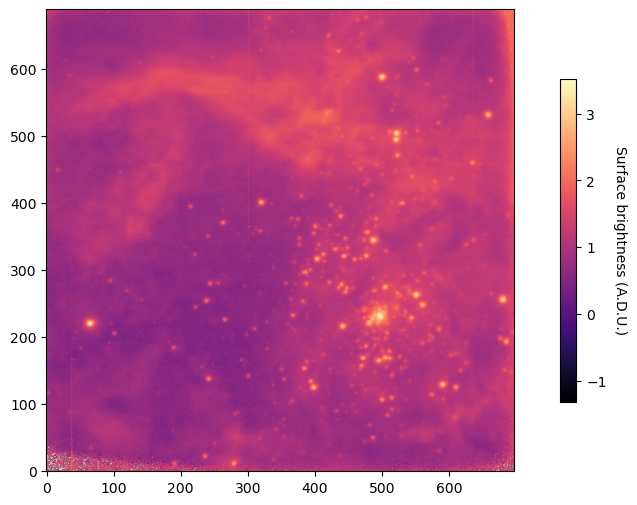

In [10]:
fig, (axx) = plt.subplots(
    1,
    1,
    sharey=True,
    figsize=(12, 6),
)
#imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
#im = ax.imshow(vv,vmin = 120, vmax=220,**imshow_kwds)
#im.cmap.set_bad(color='gray')
#cbar = fig.colorbar(im, ax=[ax], shrink=0.7)
#cbar.set_label("Radial Velocity [km/s]", rotation=270, labelpad=15)
im = axx.imshow(np.log10(continuum_img_data), **imshow_kwds2)
#im.cmap.set_bad(color='gray')
cbar = fig.colorbar(im, ax=[axx], shrink=0.7)
cbar.set_label("Surface brightness (A.D.U.)", rotation=270, labelpad=15)
#fig.suptitle(plot_label, y=0.8)

#plt.savefig('Imgs/' + name_id + '.jpg', bbox_inches='tight')